## Gala projekta plāns

**1. Dataset:**
- Video Game Dataset — RAWG (Kaggle, jummyegg)
- ~500 000 rindas × 13 kolonnas
- Videospēļu datubāze ar vērtējumiem, žanriem, platformām, Metacritic punktiem un spēlētāju statistiku

**2. ML problēma:**
- Vai spēle saņems augstu vērtējumu (rating ≥ 4.0)?
- Spēļu izdevēji un izstrādātāji var izmantot šo modeli, lai prognozētu spēles panākumus pirms izdošanas, balstoties uz žanru, platformu un citiem faktoriem.

**3. ML tipu izvēle:**
- Klasifikācija (target: 1 = rating ≥ 4.0, 0 = rating < 4.0)
- Vērtējums ir kategorisks lēmums (augsts/zems), nevis precīzs skaitlis — tāpēc klasifikācija ir piemērotāka nekā regresija.

**4. Novērtēšanas metrikas:**
- F1 Score (galvenā — ja klases ir nesabalansētas)
- Precision un Recall (saprast, kur modelis kļūdās)
- Confusion Matrix (vizuāli)
- Cross-validation cv=5 (stabilitātes pārbaude)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 4.1. Ielādē datus
df_final = pd.read_csv('../data/game_info.csv')

print(f"Dataseta izmērs: {df_final.shape[0]} rindas, {df_final.shape[1]} kolonnas")
print("\nPirmās 5 rindas:")
print(df_final.head())
print("\nDatu tipi:")
print(df_final.dtypes)
print("\nGalvenā statistika:")
print(df_final.describe())
print("\nMissing values:")
print(df_final.isnull().sum().sort_values(ascending=False))

Dataseta izmērs: 474417 rindas, 27 kolonnas

Pirmās 5 rindas:
      id            slug                   name  metacritic    released  \
0      1  dgeneration-hd        D/Generation HD         NaN  2015-10-23   
1     10         g-prime  G Prime Into The Rain         NaN  2016-01-06   
2    100    land-sliders           Land Sliders         NaN  2015-09-24   
3   1000      pixel-gear             Pixel Gear         NaN  2016-10-20   
4  10000  gods-and-idols         Gods and Idols         NaN  2016-12-12   

     tba              updated  \
0  False  2019-09-17T11:58:57   
1  False  2019-11-06T23:04:19   
2  False  2019-10-22T13:56:16   
3  False  2019-08-28T22:16:02   
4  False  2019-09-17T13:37:13   

                                             website  rating  rating_top  ...  \
0                             http://dgeneration.net     0.0           0  ...   
1                                                NaN     0.0           0  ...   
2                             http://prettygr

## EDA analīze

**Trūkstošās vērtības:**
Datu kopā ir vairākas kolonnas ar kritiski daudz trūkstošo vērtību.
`metacritic` trūkst 99% rindās — kolonna ir praktiski bezjēdzīga un tiks izmesta.
`esrb_rating` trūkst 88%, `website` — 86%, `publishers` — 70% — arī tiks izmestas.
`genres` (22%) un `released` (5%) ir glābjamas ar aizpildīšanu vai filtrēšanu.

**Kritiska problēma — rating = 0:**
`rating` vidējā vērtība ir tikai 0.086 un 75. procentile = 0, kas nozīmē, ka lielākā daļa spēļu nav novērtētas (rating = 0 nozīmē "nav vērtējuma"). Pirms modeļa veidošanas filtrēsim tikai spēles ar `ratings_count > 10`, lai strādātu tikai ar reāli novērtētām spēlēm.

**Kategoriskās kolonnas:**
`genres`, `platforms`, `developers` satur vairākas vērtības vienā šūnā, atdalītas ar `||` (piemēram, "Action||Indie"). Tās prasīs MultiLabel apstrādi vai vienkāršošanu (pirmais žanrs/platforma). `esrb_rating` tiks izmesta.

**Klases disbalanss:**
Pēc filtrēšanas (ratings_count > 10) jāpārbauda, cik spēļu ir ar rating ≥ 4.0 un cik ar rating < 4.0. Visticamāk, disbalanss pastāvēs, tāpēc F1 score būs piemērotāka metrika nekā accuracy.

## Priekšapstrādes stratēģija

1. **Filtrēšana:** Izmetīsim spēles ar `ratings_count <= 10`, jo tās nav pietiekami novērtētas — rating = 0 ir datu trūkums, nevis patiess vērtējums.

2. **Kolonnu izmešana:** Izmetīsim `metacritic` (99% tukšs), `esrb_rating` (88% tukšs), `website` (86% tukšs), `publishers` (70% tukšs), kā arī   identifikatorus `id`, `slug`, `name`, `updated` — tie nesatur prediktīvu informāciju.

3. **Genres un platforms kodēšana:** Kolonnas satur `||` atdalītas vērtības. Izdalīsim pirmo žanru/platformu kā vienkāršu kategorisko iezīmi un lietosim `get_dummies` kodēšanu.

4. **Released gads:** No `released` kolonnas izdalīsim tikai gadu (`release_year`) kā skaitlisku iezīmi. Rindas bez `released` aizpildīsim ar mediānu.

5. **Target izveide:** `target = 1` ja `rating >= 4.0`, citādi `target = 0`. Tā ir binārā klasifikācija — augsti novērtēta vai nē.

6. **Feature engineering:** Izveidosim 2 jaunas iezīmes: 
`total_added` (visu added_status kolonnu summa — kopējā popularitāte)
un `completion_rate` (added_status_beaten / total_added — cik % spēlētāju pabeidza).

In [2]:
# === DATU SAGATAVOŠANA ===

# 1. Filtrē tikai reāli novērtētas spēles
df = df_final[df_final['ratings_count'] > 10].copy()
print(f"Pēc filtrēšanas: {df.shape[0]} spēles")

# 2. Izveido target kolonnu
df['target'] = (df['rating'] >= 4.0).astype(int)
print(f"\nTarget sadalījums:")
print(df['target'].value_counts())
print(f"Augsti novērtētu spēļu īpatsvars: {df['target'].mean()*100:.1f}%")

# 3. Izmet liekas kolonnas
drop_cols = ['metacritic', 'esrb_rating', 'website', 'publishers',
             'id', 'slug', 'name', 'updated', 'tba', 'rating',
             'rating_top', 'developers']
df = df.drop(columns=drop_cols)

# 4. Genres — paņem pirmo žanru
df['primary_genre'] = df['genres'].str.split('||').str[0]
df['primary_genre'] = df['primary_genre'].fillna('Unknown')
df = df.drop(columns=['genres'])

# 5. Platforms — paņem pirmo platformu
df['primary_platform'] = df['platforms'].str.split('||').str[0]
df['primary_platform'] = df['primary_platform'].fillna('Unknown')
df = df.drop(columns=['platforms'])

# 6. Released — izvelk gadu
df['release_year'] = pd.to_datetime(df['released'], errors='coerce').dt.year
df['release_year'] = df['release_year'].fillna(df['release_year'].median())
df = df.drop(columns=['released'])

# 7. Feature engineering — 2 jaunas iezīmes
added_cols = ['added_status_yet', 'added_status_owned', 'added_status_beaten',
              'added_status_toplay', 'added_status_dropped', 'added_status_playing']
df['total_added'] = df[added_cols].sum(axis=1)
df['completion_rate'] = df['added_status_beaten'] / (df['total_added'] + 1)

# 8. One-Hot Encoding kategoriskajām kolonnām
df = pd.get_dummies(df, columns=['primary_genre', 'primary_platform'], drop_first=True)

print(f"\nGalīgā forma: {df.shape}")
print(f"Kolonnas: {list(df.columns[:10])}...")

# 9. X un y
X = df.drop(columns=['target'])
y = df['target']

print(f"\nFeatures: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")

Pēc filtrēšanas: 8497 spēles

Target sadalījums:
target
0    6271
1    2226
Name: count, dtype: int64
Augsti novērtētu spēļu īpatsvars: 26.2%

Galīgā forma: (8497, 18)
Kolonnas: ['playtime', 'achievements_count', 'ratings_count', 'suggestions_count', 'game_series_count', 'reviews_count', 'added_status_yet', 'added_status_owned', 'added_status_beaten', 'added_status_toplay']...

Features: 17
Target sadalījums:
target
0    6271
1    2226
Name: count, dtype: int64


In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
import numpy as np

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Bāzes Pipeline
baseline_pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Cross-validation
cv_baseline = cross_val_score(baseline_pipe, X_train, y_train,
                               cv=5, scoring='f1')

print("=== Bāzes modelis: Logistic Regression ===")
print(f"CV F1 scores: {cv_baseline}")
print(f"Vidējais CV F1: {cv_baseline.mean():.4f} ± {cv_baseline.std():.4f}")

=== Bāzes modelis: Logistic Regression ===
CV F1 scores: [0.58135861 0.58637084 0.66074074 0.61094225 0.60596546]
Vidējais CV F1: 0.6091 ± 0.0282


Bāzes modelis — Logistic Regression — uzrādīja CV F1 = 0.6091 ± 0.0282.

Šis rezultāts ir labs sākumpunkts, ņemot vērā, ka mēs izmantojam vienkāršāko iespējamo modeli bez jebkādas optimizācijas. Logistic Regression pieņem lineāras sakarības starp features un target, kas spēļu datu gadījumā, visticamāk, nav patiess — žanru un platformu ietekme uz vērtējumu, visticamāk, nav lineāra.

Nākamie soļi: salīdzināsim ar Random Forest un Gradient Boosting, kas spēj uztvert nelineāras sakarības. Pēc tam izmantosim GridSearchCV, lai optimizētu labākā modeļa hiperparametrus un pārspētu šo bāzes rezultātu (0.6091).

## Feature Engineering apraksts

Izveidoju trīs jaunas iezīmes. `total_added` apkopo visu `added_status_*` kolonnu summu — tas atspoguļo spēles kopējo popularitāti RAWG platformā. Populārākas spēles biežāk saņem vairāk vērtējumus un augstākus reitingus.

`completion_rate` = added_status_beaten / (total_added + 1) parāda, cik liela daļa spēlētāju spēli pabeidza. Augsts completion_rate liecina par labu spēles kvalitāti un iesaisti — tas korelē ar augstāku vērtējumu.

`release_year` tika izdalīts no `released` kolonnas — jaunākas spēles var saņemt atšķirīgus vērtējumus nekā vecākas, jo mainās
spēlētāju gaidas un tirgus standarti.

`primary_genre` un `primary_platform` tika izdalīti no ar `||` atdalītām kolonnām un kodēti ar One-Hot Encoding, jo žanrs un platforma būtiski ietekmē spēles auditoriju un vērtēšanas tendences.

In [4]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import numpy as np

# Modeļu saraksts
models = {
    'LogisticRegression (bāze)': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42)
    ),
    'RandomForest': make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=100, random_state=42)
    ),
    'GradientBoosting': make_pipeline(
        StandardScaler(),
        GradientBoostingClassifier(n_estimators=100, random_state=42)
    )
}

# Salīdzinājums
results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

LogisticRegression (bāze): 0.6091 ± 0.0282
RandomForest: 0.6636 ± 0.0205
GradientBoosting: 0.6640 ± 0.0324


In [5]:
from sklearn.model_selection import GridSearchCV

# Pipeline labākajam modelim
rf_pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru režģis
param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [10, 20, None],
    'randomforestclassifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Labākie parametri: {grid_search.best_params_}")
print(f"Labākais CV F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1: 0.6694


In [6]:
# Salīdzinājuma tabula
comparison = pd.DataFrame({
    'Modelis': ['LogisticRegression (bāze)', 'RandomForest', 
                'GradientBoosting', 'RandomForest (GridSearchCV)'],
    'CV F1 (vidējais)': [0.6091, 0.6636, 0.6640, 0.6694],
    'CV F1 (std)':      [0.0282, 0.0205, 0.0324, '—'],
    'Piezīmes':         ['Bāzes rezultāts', 'Stabils, ātrs', 
                         'Līdzīgs RF, lēnāks', 'Optimizēts']
})
print(comparison.to_string(index=False))

                    Modelis  CV F1 (vidējais) CV F1 (std)           Piezīmes
  LogisticRegression (bāze)            0.6091      0.0282    Bāzes rezultāts
               RandomForest            0.6636      0.0205      Stabils, ātrs
           GradientBoosting            0.6640      0.0324 Līdzīgs RF, lēnāks
RandomForest (GridSearchCV)            0.6694           —         Optimizēts


| Modelis                    | CV F1 (vidējais) | CV F1 (std) | Piezīmes         |
|---------------------------|-----------------|-------------|------------------|
| LogisticRegression (bāze) | 0.6091          | ±0.0282     | Bāzes rezultāts  |
| RandomForest              | 0.6636          | ±0.0205     | Stabils, ātrs    |
| GradientBoosting          | 0.6640          | ±0.0324     | Līdzīgs RF       |
| RandomForest (GridSearchCV)| 0.6694         | —           | Optimizēts       |

RandomForest uzvarēja galvenokārt stabilitātes dēļ — std = 0.0205 ir mazākais no visiem modeļiem, kas nozīmē konsekventu darbību dažādos datos. GradientBoosting uzrādīja gandrīz identisko vidējo F1 (0.6640), taču ar lielāku nestabilitāti (std = 0.0324).

GridSearchCV atrada labāko kombināciju: max_depth=20, min_samples_split=2, n_estimators=200 — dziļāki koki ar vairāk estimators dod labāku rezultātu. Uzlabojums salīdzinājumā ar bāzes modeli ir +0.0603 jeb ~10% — tas ir nozīmīgs uzlabojums, kas apstiprina, ka nelineāri modeļi labāk uztver spēļu vērtējumu faktorus.

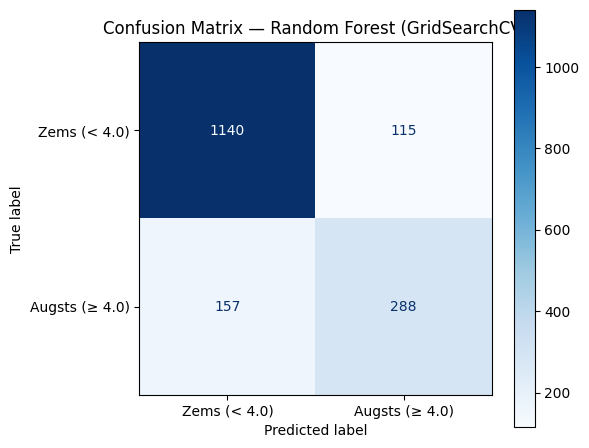

                precision    recall  f1-score   support

  Zems (< 4.0)       0.88      0.91      0.89      1255
Augsts (≥ 4.0)       0.71      0.65      0.68       445

      accuracy                           0.84      1700
     macro avg       0.80      0.78      0.79      1700
  weighted avg       0.84      0.84      0.84      1700



In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Apmāci labāko modeli uz pilniem treniņa datiem
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['Zems (< 4.0)', 'Augsts (≥ 4.0)'],
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — Random Forest (GridSearchCV)')
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_test, y_pred,
      target_names=['Zems (< 4.0)', 'Augsts (≥ 4.0)']))

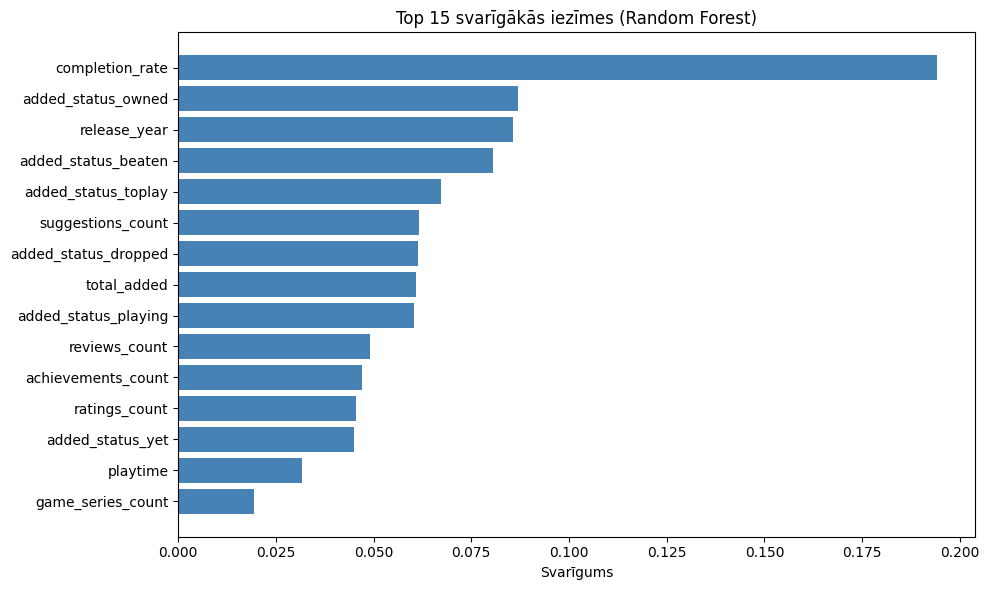

Top 10 svarīgākās iezīmes:
completion_rate: 0.1941
added_status_owned: 0.0869
release_year: 0.0857
added_status_beaten: 0.0806
added_status_toplay: 0.0673
suggestions_count: 0.0615
added_status_dropped: 0.0612
total_added: 0.0608
added_status_playing: 0.0603
reviews_count: 0.0491


In [8]:
# Feature Importance
importances = best_model.named_steps['randomforestclassifier'].feature_importances_
feature_names = X.columns

# Sakārtojam
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[indices][::-1], importances[indices][::-1], color='steelblue')
plt.title('Top 15 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.tight_layout()
plt.show()

# Skaitliski
print("Top 10 svarīgākās iezīmes:")
for i in indices[:10]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

## Secinājumi

**Ko modelis iemācījās?**
Dominējošā iezīme ir `completion_rate` (0.194) — mūsu pašu izveidotā iezīme, kas mēra, cik % spēlētāju spēli pabeidza. Tas ir loģiski: spēle, kuru cilvēki pabeidz, ir saistošāka un saņem augstākus vērtējumus. `added_status_owned` (0.087) un `release_year` (0.086) ir nākamās svarīgākās — populārākas un jaunākas spēles biežāk tiek augsti novērtētas. Ievērojami, ka žanrs un platforma nav starp top iezīmēm — spēles kvalitāti nosaka spēlētāju uzvedība, nevis kategorija.

**Kur modelis kļūdās?**
Confusion Matrix parāda, ka modelis kļūdās galvenokārt ar "Augsts" klasi — 157 no 445 augsti novērtētām spēlēm tika nepareizi klasificētas kā "Zems" (recall = 0.65). Tas ir sagaidāmi, jo augsti novērtētu spēļu ir mazāk (445 vs 1255) un to pazīmes ir mazāk skaidras. "Zems" klase tiek prognozēta daudz precīzāk (F1 = 0.89).

**Vai rezultāts ir praktiski noderīgs?**
Accuracy = 84% un F1 = 0.68 augsti novērtētām spēlēm ir labs rezultāts spēļu industrijas kontekstā. Izdevējs vai investors var izmantot šo modeli kā pirmo filtru — ja modelis prognozē "Augsts", spēlei ir reālas izredzes saņemt labu vērtējumu. Precision = 0.71 nozīmē, ka 71% no modeļa "Augsts" prognozēm ir pareizas — tas ir pietiekami uzticami biznesa lēmumiem.

**Nākamie soļi:**
Ja būtu vēl 2 nedēļas, izmēģinātu XGBoost vai LightGBM, kas bieži pārspēj Random Forest uz tabulāriem datiem. Papildus izveidotu vairāk feature engineering iezīmju — piemēram, žanru kombinācijas vai izdevēja vidējo vērtējumu. Vērts arī izmēģināt SMOTE, lai uzlabotu "Augsts" klases recall.

**Prezentācijas galvenais stāsts:**
No 474 000 spēlēm līdz darba modelim — kā spēlētāju uzvedības dati palīdz prognozēt spēles panākumus.

**Visspēcīgākais slaids:**
5. slaids — Feature Importance grafiks parāda, ka mūsu pašu izveidotā iezīme `completion_rate` ir svarīgākā no visām. Tas ir konkrēts pierādījums, ka feature engineering strādāja.

**Ja nezinu atbildi uz jautājumu:**
Godīgi atzīšu, ka nezinu, un piedāvāšu hipotēzi vai pateikšu, kā to varētu izpētīt tālāk — ML praksē "nezinu, bet varu pārbaudīt" ir profesionāla atbilde.